# Edge Detection and Segmentation Methods

Segmentation and edge detection are essential tasks in computer vision, particularly for object identification in images. One of the most commonly used techniques involves edge detectors, which help outline the shapes of objects. Among the most well-known algorithms for this purpose are Canny, Sobel, and their variations. These methods rely on identifying gradients, or abrupt changes in pixel intensity across regions of the image.

OpenCV provides efficient implementations of three gradient filters (high-pass filters): Sobel, Scharr, and Laplacian. Their corresponding functions are: cv2.Sobel(), cv2.Scharr(), and cv2.Laplacian().

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from cvutils import showImage

## Sobel

Sobel is a directional filter, which means we need to combine both the horizontal and vertical filters to achieve a complete transformation. Due to Sobel's processing, the image must be converted to a 64-bit floating-point format (which supports both positive and negative values) before being converted back to uint8.

In [2]:
imgRGB = cv2.imread('images/science.png')
img = cv2.cvtColor(imgRGB, cv2.COLOR_BGR2GRAY)

In [8]:
sobelX = cv2.Sobel(img, cv2.CV_64F, 1,0)
sobelY = cv2.Sobel(img, cv2.CV_64F, 0,1)

In [9]:
sobelX = np.uint8(np.absolute(sobelX))
sobelY = np.uint8(np.absolute(sobelY))

In [10]:
sobel = cv2.bitwise_or(sobelX,sobelY)

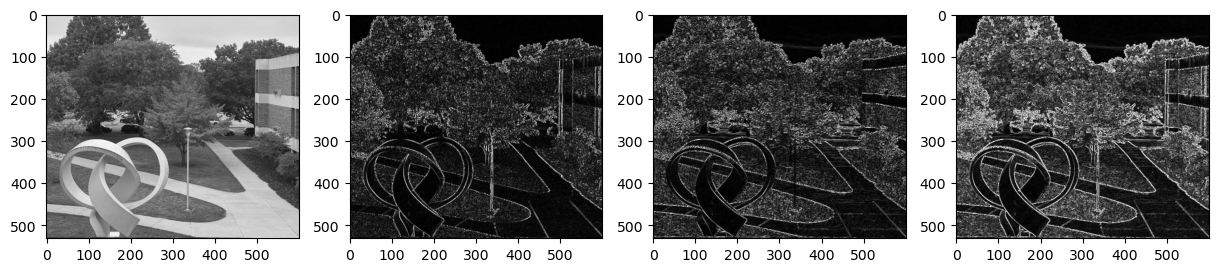

In [16]:
showImage(img,sobelX,sobelY,sobel)

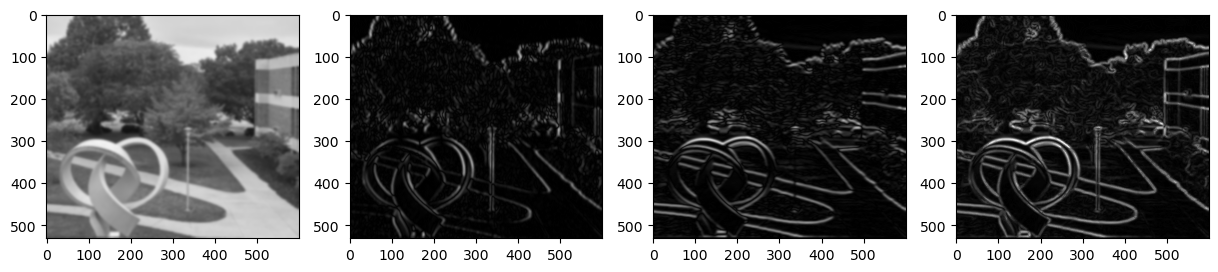

In [34]:
gaussian_blur = cv2.GaussianBlur(img, (15,15), 0)

sobelBlurX = cv2.Sobel(gaussian_blur, cv2.CV_64F, 1,0)
sobelBlurY = cv2.Sobel(gaussian_blur, cv2.CV_64F, 0,1)

sobelBlurX = np.uint8(np.absolute(sobelBlurX))
sobelBlurY = np.uint8(np.absolute(sobelBlurY))

sobelBlur = cv2.bitwise_or(sobelBlurX,sobelBlurY)

showImage(gaussian_blur,sobelBlurX,sobelBlurY,sobelBlur)

In [ ]:
sobelX_kernel = np.array([[-1, 0, 1],
                          [-2, 0, 2],
                          [-1, 0, 1]])

sobelY_kernel = np.array([[-1, -2, -1],
                          [ 0,  0,  0],
                          [ 1,  2,  1]])

## Laplacian filter

The Laplacian filter does not require separate horizontal and vertical processing like Sobel. A single step is enough to generate the resulting image. However, it also requires working with a 64-bit floating-point pixel representation before converting it back to an 8-bit unsigned integer.

In [35]:
lap = cv2.Laplacian(img,cv2.CV_64F)
lap = np.uint8(np.absolute(lap))

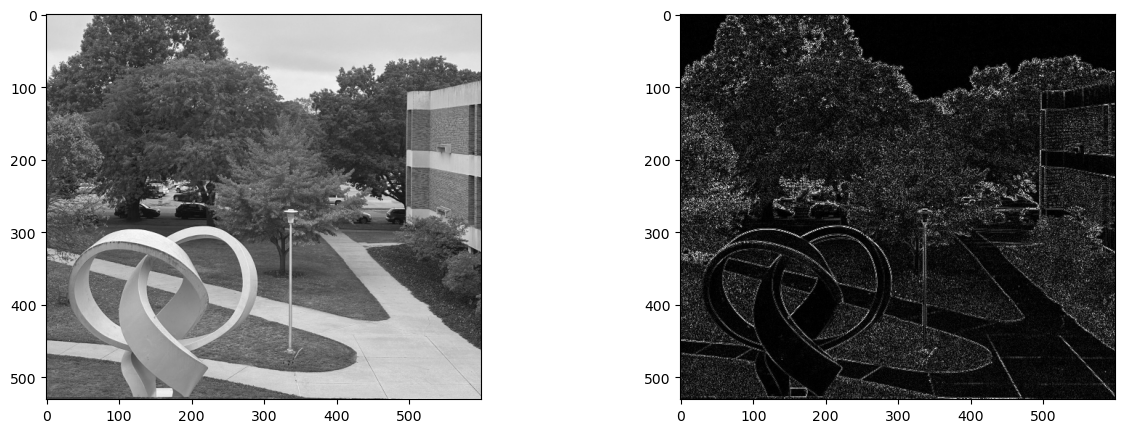

In [36]:
showImage(img,lap)

## Canny edge detector

The Canny edge detector utilizes several techniques, including Sobel, and performs multiple steps to achieve the final result. The basic steps of the Canny process are:

- Apply a Gaussian filter to smooth the image and reduce noise.
- Find the intensity gradients of the image.
- Apply Sobel in both directions to identify potential edges.
- Use a "hysteresis" process to confirm if a pixel belongs to a strong edge, suppressing all weak edges not connected to strong ones.

In [51]:
gaussian_blurC = cv2.GaussianBlur(img, (5,5), 0)

canny1 = cv2.Canny(img, 50,100)
canny2 = cv2.Canny(img, 100,200)
canny3 = cv2.Canny(gaussian_blurC, 100,200)

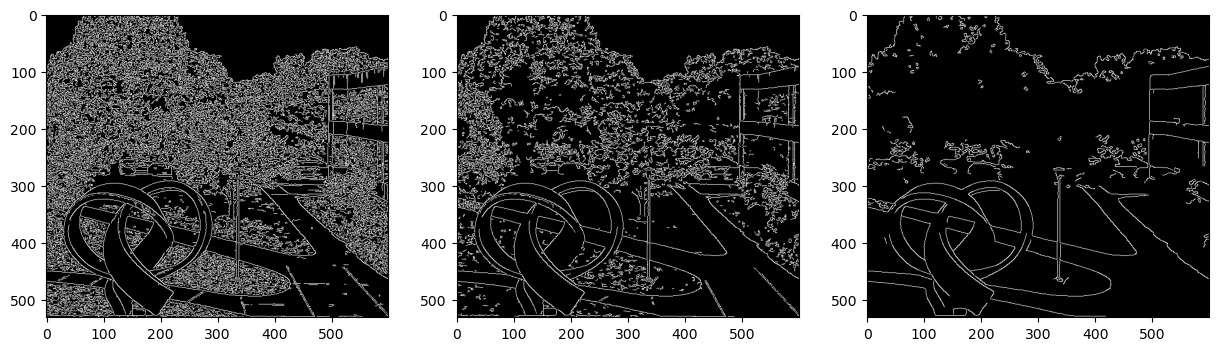

In [52]:
showImage(canny1,canny2,canny3)

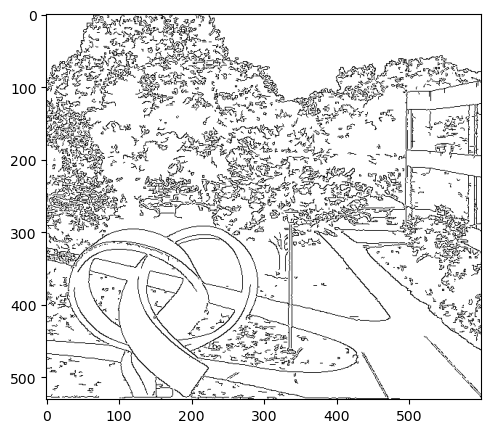

In [56]:
invertImg = cv2.bitwise_not(canny2)
showImage(invertImg)